<a href="https://colab.research.google.com/github/fergogu27-ctrl/EDPII/blob/main/Tarea_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
# Función objetivo
# max z = -2x1 - x2
z = np.array([-2, -1], dtype=float)

# Restricciones:
# x1 + x2 <= 5
# 2x1 + 3x2 <= 2
# x1 <= 4
A = np.array([
    [1, 1],
    [2, 3],
    [1, 0]
], dtype=float)

b = np.array([5, 2, 4], dtype=float)


# minimizamos -z, en linprong es maximizar por eso es -z
res = linprog(
    c=-z,
    A_ub=A,
    b_ub=b,
    bounds=[(0, None), (0, None)],
    method="highs"
)


print("x óptimo =", res.x)
print("z máximo =", z @ res.x)

x óptimo = [0. 0.]
z máximo = 0.0


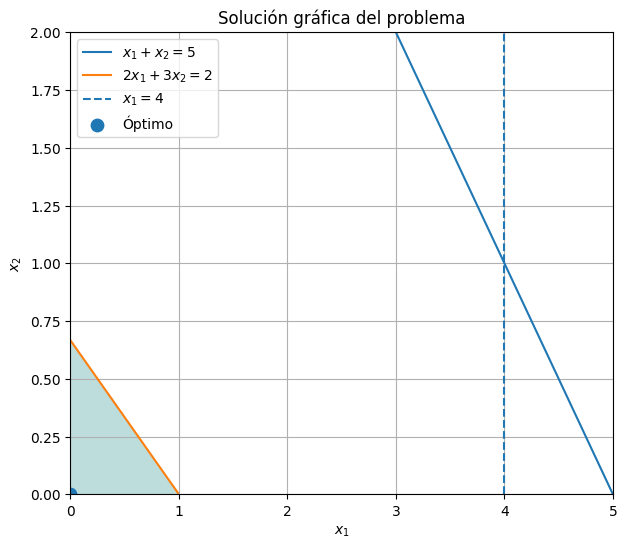

In [2]:
x = np.linspace(0, 5, 400)

# Rectas de las restricciones dadas en el problema
y1 = 5 - x                 # x1 + x2 = 5
y2 = (2 - 2*x) / 3         # 2x1 + 3x2 = 2

# SE utiliza ara evitar graficar valores negativos
y1 = np.where(y1 >= 0, y1, np.nan)
y2 = np.where(y2 >= 0, y2, np.nan)

plt.figure(figsize=(7, 6))
plt.plot(x, y1, label=r"$x_1+x_2=5$")
plt.plot(x, y2, label=r"$2x_1+3x_2=2$")
plt.axvline(4, linestyle="--", label=r"$x_1=4$")

# Región factible por malla
X, Y = np.meshgrid(np.linspace(0, 5, 500), np.linspace(0, 2, 500))
factible = (
    (X + Y <= 5) &
    (2*X + 3*Y <= 2) &
    (X <= 4) &
    (X >= 0) &
    (Y >= 0)
)

plt.contourf(X, Y, factible, levels=[0.5, 1], alpha=0.3)

# Punto óptimo solucioón
x_opt = res.x[0]
y_opt = res.x[1]
plt.scatter(x_opt, y_opt, s=80, label="Óptimo")

plt.xlim(0, 5)
plt.ylim(0, 2)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Solución gráfica del problema")
plt.grid(True)
plt.legend()
plt.show()